# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import re
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings('ignore')

## 2. Datos

In [2]:
df_kaggle = pd.read_csv('./data/train.csv', encoding='latin-1')
df = df_kaggle.copy()

### 2.1 Exploración de los datos

In [3]:
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

Shape: (912, 13)
Columnas: ['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_in_euros']


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [5]:
print("Nulos por columna:")
print(df.isnull().sum())

print(f"\nTarget (Price_in_euros):")
print(df['Price_in_euros'].describe().round(2))

print(f"\nSkew del precio: {df['Price_in_euros'].skew():.2f}")
print(f"Skew del log(precio): {np.log1p(df['Price_in_euros']).skew():.2f}")
# El precio tiene skew fuerte a la derecha (pocos portátiles muy caros "estiran" la distribución).
# log1p lo reduce mucho -> en 4.1 entrenamos sobre log1p(precio) con TransformedTargetRegressor.

Nulos por columna:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64

Target (Price_in_euros):
count     912.00
mean     1111.72
std       687.96
min       174.00
25%       589.00
50%       978.00
75%      1483.94
max      6099.00
Name: Price_in_euros, dtype: float64

Skew del precio: 1.44
Skew del log(precio): -0.22


In [6]:
for col in ['TypeName','Company','OpSys']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


TypeName:
TypeName
Notebook              509
Gaming                143
Ultrabook             141
2 in 1 Convertible     80
Workstation            20
Netbook                19

Company:
Company
Lenovo       202
Dell         197
HP           194
Asus         121
Acer          74
MSI           37
Toshiba       34
Apple         17
Razer          6
Mediacom       6
Samsung        5
Microsoft      5
Xiaomi         3
Huawei         2
Chuwi          2
Google         2
Vero           2
Fujitsu        2
LG             1

OpSys:
OpSys
Windows 10      741
Linux            48
No OS            44
Windows 7        29
Chrome OS        24
macOS            11
Windows 10 S      7
Mac OS X          6
Android           2


Las columnas **Ram**, **Weight**, **ScreenResolution**, **Cpu**, **Gpu** y **Memory** contienen info necesaria en string, que hay q convertir.

| *Columna original* | *Features extraídas* |
|---|---|
| **Ram** | **Ram_GB** (int) |
| **Weight** | **Weight_kg** (float) |
| **ScreenResolution** | **IPS**, **Touchscreen**, **Res_W**, **Res_H**, **PPI** |
| **Cpu** | **Cpu_brand**, **Cpu_type**, **Cpu_GHz** |
| **Gpu** | **Gpu_brand** |
| **Memory** | **SSD_GB**, **HDD_GB**, **Flash_GB**, **Total_storage**, **Has_SSD**, **Has_HDD**, **Has_Both** |

In [7]:
CAT_FEATURES = ['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_type', 'Gpu_brand']

NUM_FEATURES = [
    'Inches', 'Ram_GB', 'Weight_kg',
    'IPS', 'Touchscreen', 'Res_W', 'Res_H', 'PPI',
    'Cpu_GHz',
    'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_storage',
    'Has_SSD', 'Has_HDD', 'Has_Hybrid', 'Has_Both',
]


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Parsea las columnas de texto crudas (Ram, Weight, ScreenResolution, Cpu, Gpu, Memory)
    en las features numéricas/categóricas de la tabla de arriba.

    Es un transformer "stateless": fit() no aprende nada de los datos, solo re-parsea
    texto fila a fila. Por eso es seguro meterlo en un Pipeline y usarlo igual en train
    y test sin fuga de información -- a diferencia de un LabelEncoder ajustado por
    separado en cada uno (lo que hacía la versión anterior de este notebook), que
    causaba un bug real: Company no tiene 'Huawei' en test y OpSys no tiene 'Android',
    así que los códigos numéricos asignados no coincidían entre train y test.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Ram: "8GB" → 8
        df['Ram_GB'] = df['Ram'].str.replace('GB', '').astype(int)

        # Weight: "2.2kg" → 2.2
        df['Weight_kg'] = df['Weight'].str.replace('kg', '', case=False).astype(float)

        # ScreenResolution: flags + resolución + PPI
        df['IPS']         = df['ScreenResolution'].str.contains('IPS').astype(int)
        df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen|Touch').astype(int)
        res               = df['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')
        df['Res_W']       = res[0].astype(float)
        df['Res_H']       = res[1].astype(float)
        df['PPI']         = np.sqrt(df['Res_W']**2 + df['Res_H']**2) / df['Inches']

        # CPU: marca, tipo de core, velocidad
        df['Cpu_brand'] = df['Cpu'].apply(
            lambda x: 'Intel' if 'Intel' in str(x) else ('AMD' if 'AMD' in str(x) else 'Other'))
        df['Cpu_type'] = df['Cpu'].apply(lambda x:
            'i9' if 'i9' in str(x) else ('i7' if 'i7' in str(x) else
            ('i5' if 'i5' in str(x) else ('i3' if 'i3' in str(x) else
            ('Ryzen' if 'Ryzen' in str(x) else ('Celeron' if 'Celeron' in str(x) else
            ('Xeon' if 'Xeon' in str(x) else 'Other')))))))
        df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)

        # GPU: marca
        df['Gpu_brand'] = df['Gpu'].apply(
            lambda x: 'Nvidia' if 'Nvidia' in str(x) else ('Intel' if 'Intel' in str(x) else
            ('AMD' if 'AMD' in str(x) else 'Other')))

        # Memory: extraer GB de SSD/HDD/Flash/Hybrid
        # (la versión anterior no contaba 'Hybrid': algunas filas quedaban a 0 en todo,
        #  perdiendo esa información de almacenamiento)
        def parse_memory(mem_str):
            ssd, hdd, flash, hybrid = 0, 0, 0, 0
            for part in str(mem_str).replace('+', '|').split('|'):
                part = part.strip()
                matches = re.findall(r'[\d.]+', part)
                val = float(matches[0]) * (1024 if 'TB' in part else 1) if matches else 0
                if   'Hybrid' in part: hybrid += val
                elif 'SSD'    in part: ssd    += val
                elif 'HDD'    in part: hdd    += val
                elif 'Flash'  in part or 'eMMC' in part: flash += val
            return pd.Series({'SSD_GB': ssd, 'HDD_GB': hdd, 'Flash_GB': flash, 'Hybrid_GB': hybrid})

        mem_df = df['Memory'].apply(parse_memory)
        df = pd.concat([df, mem_df], axis=1)
        df['Total_storage'] = df['SSD_GB'] + df['HDD_GB'] + df['Flash_GB'] + df['Hybrid_GB']
        df['Has_SSD']    = (df['SSD_GB'] > 0).astype(int)
        df['Has_HDD']    = (df['HDD_GB'] > 0).astype(int)
        df['Has_Hybrid'] = (df['Hybrid_GB'] > 0).astype(int)
        df['Has_Both']   = ((df['SSD_GB'] > 0) & (df['HDD_GB'] > 0)).astype(int)

        return df[CAT_FEATURES + NUM_FEATURES]


print(f"Features finales: {len(CAT_FEATURES) + len(NUM_FEATURES)}")
print("Categóricas:", CAT_FEATURES)
print("Numéricas:", NUM_FEATURES)

Features finales: 24
Categóricas: ['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_type', 'Gpu_brand']
Numéricas: ['Inches', 'Ram_GB', 'Weight_kg', 'IPS', 'Touchscreen', 'Res_W', 'Res_H', 'PPI', 'Cpu_GHz', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_storage', 'Has_SSD', 'Has_HDD', 'Has_Hybrid', 'Has_Both']


### 2.2 Definir X e y


In [8]:
X = df.drop(columns=['Price_in_euros', 'laptop_ID'])
y = df['Price_in_euros']
print(f"X: {X.shape}  |  y: {y.shape}")

# X contiene las columnas crudas tal cual vienen del CSV (Ram, Weight, ScreenResolution,
# Cpu, Gpu, Memory...). El FeatureEngineer + encoding de la tabla de arriba se aplican
# dentro del Pipeline (sección 4.1), no aquí, para poder reutilizar el mismo objeto ya
# entrenado sobre test.csv sin duplicar código (sección 7).

X: (912, 11)  |  y: (912,)


### 2.3 Dividir en train y test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (729, 11) | Test: (183, 11)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [10]:
# El encoder de categóricas se ajustará ("fit") SOLO sobre X_train, dentro del Pipeline
# de la sección 4.1 -- así se respeta la advertencia de arriba sin gestionarlo a mano.
# OrdinalEncoder (en vez de LabelEncoder) porque está pensado para vivir dentro de un
# ColumnTransformer/Pipeline: se ajusta una vez con .fit() y luego solo hace .transform().
# handle_unknown='use_encoded_value' evita que explote si aparece una categoría nunca
# vista en train (aquí no pasa, pero es buena práctica).
preprocessing = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_FEATURES),
    ('num', 'passthrough', NUM_FEATURES),
])
print("ColumnTransformer listo (categóricas con OrdinalEncoder, numéricas sin tocar).")

ColumnTransformer listo (categóricas con OrdinalEncoder, numéricas sin tocar).


## 4. Modelado

### 4.1 Entrenamiento

In [11]:
lgbm = lgb.LGBMRegressor(
    n_estimators    = 800,
    learning_rate   = 0.03,
    num_leaves      = 63,
    min_child_samples = 10,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbose         = -1,
)

base_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing',       preprocessing),
    ('model',               lgbm),
])

# TransformedTargetRegressor entrena sobre log1p(precio) y deshace la transformación
# automáticamente al predecir (expm1) -- ver el análisis de skew en 2.1.
model = TransformedTargetRegressor(
    regressor=base_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [12]:
y_pred_val = model.predict(X_test)
rmse_val   = root_mean_squared_error(y_test, y_pred_val)
print(f"RMSE en validación: {rmse_val:.2f} €")

RMSE en validación: 295.48 €


### 4.3 Optimización (up to you 🫰🏻)

- Feature importanece [fi]

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model, X, y, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
)
rmse_folds = -scores

print("RMSE por fold:", np.round(rmse_folds, 2))
print(f"RMSE medio (CV): {rmse_folds.mean():.2f} € (+/- {rmse_folds.std():.2f})")
# Con ~900 filas, el split 80/20 de la sección 2.3 puede variar bastante según qué filas
# caigan en el 20% de test. 5-fold CV da una estimación más robusta (cada fila valida
# exactamente una vez, usando en cada fold un Pipeline ajustado desde cero solo con
# los datos de train de ese fold -- cero fugas de información).

RMSE por fold: [295.48 229.38 276.51 237.95 317.07]
RMSE medio (CV): 271.28 € (+/- 33.39)


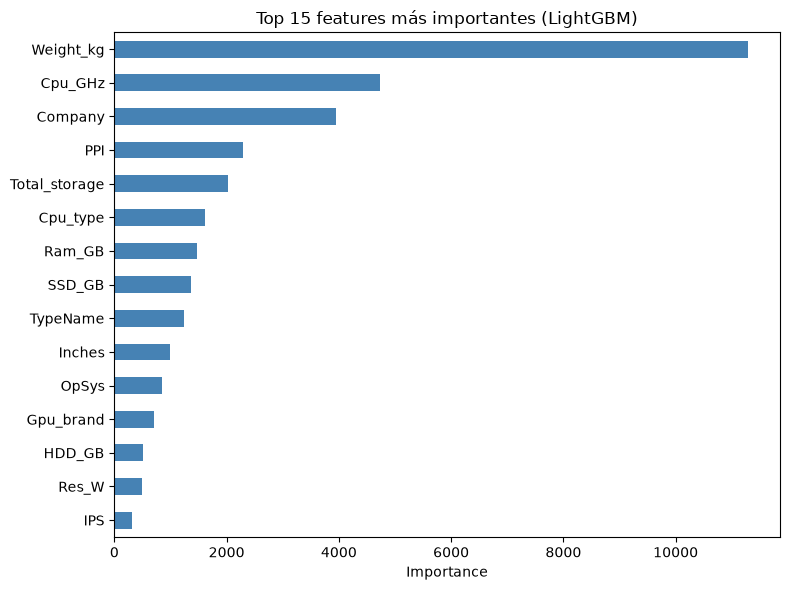

Weight_kg        11294
Cpu_GHz           4738
Company           3952
PPI               2294
Total_storage     2032
Cpu_type          1616
Ram_GB            1472
SSD_GB            1363
TypeName          1245
Inches             985


In [14]:
fitted_lgbm = model.regressor_.named_steps['model']
encoded_feature_names = CAT_FEATURES + NUM_FEATURES  # mismo orden que en el ColumnTransformer

fi = (pd.Series(fitted_lgbm.feature_importances_, index=encoded_feature_names)
       .sort_values(ascending=False))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
fi.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 features más importantes (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(fi.head(10).to_string())

## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [15]:
final_lgbm = lgb.LGBMRegressor(
    n_estimators    = 800,
    learning_rate   = 0.03,
    num_leaves      = 63,
    min_child_samples = 10,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbose         = -1,
)

# Reconstruimos el ColumnTransformer (en vez de reutilizar `preprocessing`) para no
# pisar el que ya quedó ajustado sobre X_train y usado en las secciones 4.2 y 4.3.
final_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', ColumnTransformer(transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_FEATURES),
        ('num', 'passthrough', NUM_FEATURES),
    ])),
    ('model', final_lgbm),
])

final_model = TransformedTargetRegressor(
    regressor=final_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

final_model.fit(X, y)
print(f"Modelo final entrenado sobre {X.shape[0]} muestras.")

Modelo final entrenado sobre 912 muestras.


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [16]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [17]:
X_pred_final = X_pred.drop(columns=['laptop_ID'])

print(f"Shape test procesado: {X_pred_final.shape}")
print(f"Nulos: {X_pred_final.isnull().sum().sum()}")
X_pred_final.head()

# Gracias al Pipeline no hace falta llamar a engineer_features a mano ni repetir el
# encoding: final_model.predict() aplica automáticamente FeatureEngineer.transform(),
# preprocessing.transform() (nunca fit_transform) y el expm1 de vuelta del log-target.

Shape test procesado: (391, 11)
Nulos: 0


,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [18]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [19]:
predictions = final_model.predict(X_pred_final)

submission = pd.DataFrame({
    'laptop_ID':      X_pred['laptop_ID'],
    'Price_in_euros': predictions,
})

print(f"Shape: {submission.shape}")
print(f"Precio medio predicho: {predictions.mean():.2f}€")
submission.head()

Shape: (391, 2)
Precio medio predicho: 1114.91€


,laptop_ID,Price_in_euros
0,209,1275.547191
1,1281,282.694982
2,1168,388.336517
3,1231,915.062766
4,1020,1061.138896


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [20]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [21]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260702_194825.csv'. ¡A Kaggle!
